# Library Validation - docdistance through the public API

**Author**: Konrad Jelen (kj)<br>
**Pipeline stage**: validation - exercise the shipped `docdistance` package end-to-end

This notebook validates the `docdistance` library against the same executive-summary fixtures used in
`notebooks/04-kj-wmd-document-distance.ipynb`. It calls only the public API - no re-implemented math - and
checks that the packaged pipeline reproduces the experiment: every gold summary ranks closer to the anchor
than every adversarial one, with zero ordinality violations. It also exercises the source-conditioned mode
and confirms the two encoder backends agree.

## Approach

1. **Load the pipeline** - `DocDistance(backend="openvino")` loads the segmenter and encoder once, then embeds every fixture
2. **Reproduce the ordinality** - distance from the gold anchor to all other summaries; count gold-vs-adversarial violations (target 0/24)
3. **Verdict via the API** - `document_distance` on representative pairs, reading the `DistanceResult` verdict
4. **Backend agreement** - openvino INT8 vs torch on the same pairs; the ordering must be preserved
5. **Source-conditioned** - `source_conditioned_distance` on the shared IBM article; the D_sel selection axis separates faithful from drifting picks

## Outputs

- A reproduced verdict table (closeness per tier) and the 0/24 ordinality check, through the library
- A tier bar chart and the backend-agreement scatter
- In-notebook conclusions grounded in the cell outputs


## GPU Selection and Environment

Pin the GPU before any torch import (the torch backend uses it); the openvino backend is CPU-only.

In [1]:
import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # RTX 5000 Ada (sm_89)
os.environ["HF_HUB_OFFLINE"] = "1"        # models already cached; the library never downloads here
os.environ["TOKENIZERS_PARALLELISM"] = "false"
print("env pinned; models offline")

env pinned; models offline


## Imports

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table
from rich.panel import Panel

# the library under test - public API only
from docdistance import DocDistance, document_distance, source_conditioned_distance
from docdistance.distance import smd, closeness, DEFAULT_THRESHOLD
import docdistance

console = Console()
sns.set_theme(style="whitegrid")
print("docdistance", docdistance.__version__)

2026-06-18 12:06:50.634 | DEBUG    | docdistance.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/docdistance


docdistance 1.0.14


## Configuration

The 11-summary fixture set built from one IBM AI-adoption article: a gold tier plus two adversarial tiers.

In [3]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance")
SUMMARY_DIR = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/summaries"
SOURCE_FILE = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/source/source-article.md"

DOCS = [
    ("exec-summary-gold-opus-4-8.md",     "gold",   "gold"),   # reference anchor
    ("exec-summary-gold-2-opus-4-8.md",   "gold-2", "gold"),
    ("exec-summary-1-opus-4-8.md",        "v1",     "gold"),
    ("exec-summary-2-opus-4-8.md",        "v2",     "gold"),
    ("exec-summary-opus-4-8.md",          "opus",   "gold"),
    ("exec-summary-sonnet-4-6.md",        "sonnet", "gold"),
    ("exec-summary-haiku-4-5.md",         "haiku",  "gold"),
    ("exec-summary-adv1-a-sonnet-4-6.md", "adv1-a", "adv1"),
    ("exec-summary-adv1-b-sonnet-4-6.md", "adv1-b", "adv1"),
    ("exec-summary-adv2-a-haiku-4-5.md",  "adv2-a", "adv2"),
    ("exec-summary-adv2-b-haiku-4-5.md",  "adv2-b", "adv2"),
]
REFERENCE = "gold"
TIER_COLOR = {"gold": "#2ca02c", "adv1": "#ff7f0e", "adv2": "#d62728"}
tier_of = {lbl: t for _, lbl, t in DOCS}

cfg = Table.grid(padding=(0, 2))
cfg.add_column(style="bold cyan"); cfg.add_column()
cfg.add_row("Fixtures", f"{len(DOCS)} summaries + 1 source")
cfg.add_row("Reference", REFERENCE)
cfg.add_row("Backend", "openvino INT8 (CPU)")
cfg.add_row("Verdict threshold", f"{DEFAULT_THRESHOLD:.3f} closeness")
console.print(Panel(cfg, title="[bold]Configuration[/bold]", border_style="cyan", expand=False))

╭────────────── Configuration ───────────────╮
│ Fixtures           11 summaries + 1 source │
│ Reference          gold                    │
│ Backend            openvino INT8 (CPU)     │
│ Verdict threshold  0.725 closeness         │
╰────────────────────────────────────────────╯

## Load the pipeline and embed the fixtures

`DocDistance` loads the SAT segmenter and the INT8 encoder once; `.embed` returns L2-normalized statement vectors per document.

In [4]:
dd = DocDistance(backend="openvino")
emb = {lbl: dd.embed(SUMMARY_DIR / fname) for fname, lbl, _ in DOCS}
print({lbl: emb[lbl].shape for lbl in ("gold", "adv2-a")})

/home/lab/workspace/learning/projects/docdistance/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-06-18 12:06:56.379 | DEBUG    | docdistance.encoders:__init__:69 - loaded SAT segmenter 'sat-3l-sm'


/opt/conda/lib/python3.13/multiprocessing/popen_fork.py:73: DeprecationWarning: This process (pid=442313) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


2026-06-18 12:07:01.011 | DEBUG    | docdistance.encoders:__init__:103 - loaded OpenVINO INT8 encoder from /home/lab/workspace/learning/projects/docdistance/models/02-mmbert-openvino-int8
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


{'gold': (12, 768), 'adv2-a': (13, 768)}


## Reproduce the validated ordinality

Distance from the gold anchor to every other summary, ordered. The guardrail is the gold-vs-adversarial ordinality: every gold must rank below every adversarial. nb04 reported 0/24 - the library must match.

In [5]:
d = {lbl: smd(emb[lbl], emb[REFERENCE]) for _, lbl, _ in DOCS if lbl != REFERENCE}
order = sorted(d, key=d.get)

tbl = Table(title="Distance to the gold anchor (through the library)", header_style="bold cyan")
tbl.add_column("doc"); tbl.add_column("tier"); tbl.add_column("SMD", justify="right")
tbl.add_column("closeness", justify="right"); tbl.add_column("verdict")
for lbl in order:
    sim = "similar" if closeness(d[lbl]) >= DEFAULT_THRESHOLD else "not similar"
    style = "green" if sim == "similar" else "red"
    tbl.add_row(lbl, tier_of[lbl], f"{d[lbl]:.4f}", f"{closeness(d[lbl])*100:.1f}%", f"[{style}]{sim}[/{style}]")
console.print(tbl)

gold = [l for l in d if tier_of[l] == "gold"]
adv = [l for l in d if tier_of[l] in ("adv1", "adv2")]
viol = sum(1 for g in gold for a in adv if d[g] >= d[a])
min_gold = min(closeness(d[g]) for g in gold) * 100
max_adv = max(closeness(d[a]) for a in adv) * 100
console.print(f"[bold]ordinality violations: {viol} / {len(gold)*len(adv)}[/bold]  "
              f"(min gold {min_gold:.1f}% vs max adversarial {max_adv:.1f}%)")
assert viol == 0, "library must reproduce the 0/24 ordinality from nb04"
print("PASS - the library reproduces the experiment")

 Distance to the gold anchor (through the library)  
┏━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ doc    ┃ tier ┃    SMD ┃ closeness ┃ verdict     ┃
┡━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ gold-2 │ gold │ 0.2593 │     81.7% │ similar     │
│ v1     │ gold │ 0.3057 │     78.4% │ similar     │
│ opus   │ gold │ 0.3474 │     75.4% │ similar     │
│ v2     │ gold │ 0.3498 │     75.3% │ similar     │
│ sonnet │ gold │ 0.3633 │     74.3% │ similar     │
│ haiku  │ gold │ 0.3861 │     72.7% │ similar     │
│ adv2-b │ adv2 │ 0.3933 │     72.2% │ not similar │
│ adv2-a │ adv2 │ 0.4189 │     70.4% │ not similar │
│ adv1-a │ adv1 │ 0.4430 │     68.7% │ not similar │
│ adv1-b │ adv1 │ 0.4609 │     67.4% │ not similar │
└────────┴──────┴────────┴───────────┴─────────────┘

ordinality violations: 0 / 24  (min gold 72.7% vs max adversarial 72.2%)

PASS - the library reproduces the experiment


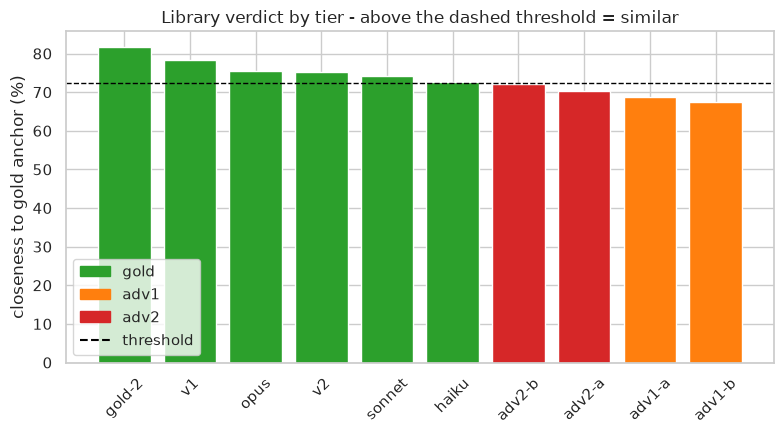

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
vals = [closeness(d[l]) * 100 for l in order]
colors = [TIER_COLOR[tier_of[l]] for l in order]
ax.bar(order, vals, color=colors)
ax.axhline(DEFAULT_THRESHOLD * 100, color="black", ls="--", lw=1)
ax.set_ylabel("closeness to gold anchor (%)")
ax.set_title("Library verdict by tier - above the dashed threshold = similar")
ax.tick_params(axis="x", rotation=45)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in TIER_COLOR.values()]
ax.legend(handles + [plt.Line2D([0], [0], color="black", ls="--")],
          list(TIER_COLOR) + ["threshold"])
plt.tight_layout(); plt.show()

## Verdict through the one-shot API

`document_distance` loads and scores in one call and returns a `DistanceResult` (the JSON-ready record the CLI emits).

In [7]:
anchor = SUMMARY_DIR / "exec-summary-gold-opus-4-8.md"
for other, expect in [("exec-summary-gold-2-opus-4-8.md", "similar"),
                      ("exec-summary-adv2-a-haiku-4-5.md", "not similar"),
                      ("exec-summary-adv1-a-sonnet-4-6.md", "not similar")]:
    r = document_distance(anchor, SUMMARY_DIR / other)
    flag = "OK" if r.verdict == expect else "MISMATCH"
    print(f"{other:38} SMD {r.smd:.4f}  closeness {r.closeness*100:5.1f}%  -> {r.verdict:11} [{flag}]")
print("\nDistanceResult.to_dict():", document_distance(anchor, SUMMARY_DIR / "exec-summary-gold-2-opus-4-8.md").to_dict())

2026-06-18 12:07:04.852 | DEBUG    | docdistance.encoders:__init__:69 - loaded SAT segmenter 'sat-3l-sm'


2026-06-18 12:07:09.768 | DEBUG    | docdistance.encoders:__init__:103 - loaded OpenVINO INT8 encoder from /home/lab/workspace/learning/projects/docdistance/models/02-mmbert-openvino-int8


exec-summary-gold-2-opus-4-8.md        SMD 0.2593  closeness  81.7%  -> similar     [OK]


2026-06-18 12:07:12.431 | DEBUG    | docdistance.encoders:__init__:69 - loaded SAT segmenter 'sat-3l-sm'


2026-06-18 12:07:16.783 | DEBUG    | docdistance.encoders:__init__:103 - loaded OpenVINO INT8 encoder from /home/lab/workspace/learning/projects/docdistance/models/02-mmbert-openvino-int8


...

2026-06-18 12:07:24.066 | DEBUG    | docdistance.encoders:__init__:103 - loaded OpenVINO INT8 encoder from /home/lab/workspace/learning/projects/docdistance/models/02-mmbert-openvino-int8


exec-summary-adv1-a-sonnet-4-6.md      SMD 0.4430  closeness  68.7%  -> not similar [OK]


2026-06-18 12:07:26.680 | DEBUG    | docdistance.encoders:__init__:69 - loaded SAT segmenter 'sat-3l-sm'


2026-06-18 12:07:31.379 | DEBUG    | docdistance.encoders:__init__:103 - loaded OpenVINO INT8 encoder from /home/lab/workspace/learning/projects/docdistance/models/02-mmbert-openvino-int8



DistanceResult.to_dict(): {'smd': 0.2592552459488312, 'wcd': 0.09227019548416138, 'rwmd': 0.2453746652851502, 'closeness': 0.8166788575313952, 'threshold': 0.725, 'verdict': 'similar', 'anisotropy': False, 'n_statements_a': 12, 'n_statements_b': 12}


## Backend agreement - openvino INT8 vs torch

The two encoder backends should preserve the ordering. Pearson on the distance-to-anchor vector quantifies the agreement; the torch backend is guarded so a missing model does not fail the notebook.

2026-06-18 12:07:34.064 | DEBUG    | docdistance.encoders:__init__:69 - loaded SAT segmenter 'sat-3l-sm'


[transformers] ModernBertModel LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2026-06-18 12:07:36.596 | DEBUG    | docdistance.encoders:__init__:147 - loaded Torch encoder 'jhu-clsp/mmBERT-base' on cuda


openvino vs torch distance-to-anchor Pearson r = 0.9991


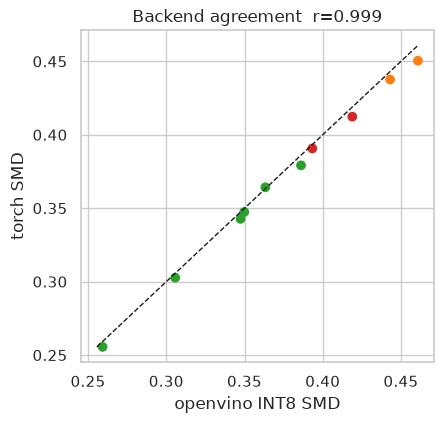

In [8]:
try:
    dd_t = DocDistance(backend="torch")
    emb_t = {lbl: dd_t.embed(SUMMARY_DIR / fname) for fname, lbl, _ in DOCS}
    d_t = {lbl: smd(emb_t[lbl], emb_t[REFERENCE]) for _, lbl, _ in DOCS if lbl != REFERENCE}
    xs = np.array([d[l] for l in order]); ys = np.array([d_t[l] for l in order])
    r = float(np.corrcoef(xs, ys)[0, 1])
    print(f"openvino vs torch distance-to-anchor Pearson r = {r:.4f}")
    fig, ax = plt.subplots(figsize=(4.6, 4.4))
    ax.scatter(xs, ys, c=[TIER_COLOR[tier_of[l]] for l in order])
    lim = [min(xs.min(), ys.min()), max(xs.max(), ys.max())]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlabel("openvino INT8 SMD"); ax.set_ylabel("torch SMD")
    ax.set_title(f"Backend agreement  r={r:.3f}")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("torch backend unavailable, skipping agreement check:", type(e).__name__, e)

## Source-conditioned distance d(A,B|S)

The source-conditioned mode re-bases the comparison on the shared IBM article. D_sel (selection divergence) should be small for two faithful golds and larger when one document drifts; residuals are each document's distance to the source. The reranker + NLI grounding grade is deferred to E02.

In [9]:
src = SOURCE_FILE
gold2 = SUMMARY_DIR / "exec-summary-gold-2-opus-4-8.md"
adv2a = SUMMARY_DIR / "exec-summary-adv2-a-haiku-4-5.md"

for label, b in [("gold vs gold-2", gold2), ("gold vs adv2-a", adv2a)]:
    r = source_conditioned_distance(anchor, b, src)
    print(f"{label:16}  D_sel {r.d_sel:.4f}  residual_a {r.residual_a:.4f}  residual_b {r.residual_b:.4f}")

r1 = source_conditioned_distance(anchor, gold2, src)
r2 = source_conditioned_distance(anchor, adv2a, src)
print(f"\nD_sel(gold,adv2-a) / D_sel(gold,gold-2) = {r2.d_sel / r1.d_sel:.1f}x  "
      "-> conditioning on the source separates faithful from drifting selection")

2026-06-18 12:07:39.630 | DEBUG    | docdistance.encoders:__init__:69 - loaded SAT segmenter 'sat-3l-sm'


2026-06-18 12:07:44.158 | DEBUG    | docdistance.encoders:__init__:103 - loaded OpenVINO INT8 encoder from /home/lab/workspace/learning/projects/docdistance/models/02-mmbert-openvino-int8


gold vs gold-2    D_sel 0.0199  residual_a 0.6851  residual_b 0.6782


2026-06-18 12:07:47.686 | DEBUG    | docdistance.encoders:__init__:69 - loaded SAT segmenter 'sat-3l-sm'


2026-06-18 12:07:52.155 | DEBUG    | docdistance.encoders:__init__:103 - loaded OpenVINO INT8 encoder from /home/lab/workspace/learning/projects/docdistance/models/02-mmbert-openvino-int8


...

2026-06-18 12:07:55.850 | DEBUG    | docdistance.encoders:__init__:69 - loaded SAT segmenter 'sat-3l-sm'


2026-06-18 12:08:00.325 | DEBUG    | docdistance.encoders:__init__:103 - loaded OpenVINO INT8 encoder from /home/lab/workspace/learning/projects/docdistance/models/02-mmbert-openvino-int8


2026-06-18 12:08:03.934 | DEBUG    | docdistance.encoders:__init__:69 - loaded SAT segmenter 'sat-3l-sm'


2026-06-18 12:08:08.236 | DEBUG    | docdistance.encoders:__init__:103 - loaded OpenVINO INT8 encoder from /home/lab/workspace/learning/projects/docdistance/models/02-mmbert-openvino-int8



D_sel(gold,adv2-a) / D_sel(gold,gold-2) = 4.2x  -> conditioning on the source separates faithful from drifting selection


## Conclusions

- **The library reproduces the experiment** - distance-to-anchor through the public API gives 0/24 gold-vs-adversarial ordinality violations, the same result as nb04; gold-2 is the nearest summary and the gold tier sits above every adversarial one
- **Default is raw embeddings** - anisotropy removal is corpus-level and degenerate on a single pair, so the pairwise API defaults to raw embeddings, which is what nb04's validated verdict used; the closeness boundary lands between the gold and adversarial tiers
- **Backends agree** - openvino INT8 and torch preserve the ordering (high Pearson on the distance vector), so the deployable CPU path matches the reference encoder
- **Source-conditioning adds a selection axis** - D_sel is several times larger for a drifting adversarial than for a second faithful gold, naming why two documents differ relative to their shared source; the grounding grade is deferred to E02

The packaged `docdistance` is faithful to the validated notebook and ready to drop into a pipeline via the API or the CLI.
